In [1]:
import re

import numpy as np
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

import pymc as pm

from tqdm.auto import tqdm as tqdm_auto
from tqdm.notebook import tqdm

In [2]:
d1 = pd.read_csv("../../data/lib2/raw/UTR5_sequence_counts_06_04_24.tsv", sep="\t", index_col=0, header=[0, 1, 2])
d1.index.name = "seq"
d1.columns.names = ["cell_type", "replicate", "bin"]
d1

cell_type                                             c2                     \
replicate                                              1                      
bin                                                    1     2     3      4   
seq                                                                           
AAAAAAAATGTGACGGCGGCGGCGGCGGCGGCGGCGGCAGCGGCGGCGGC   636   664   615   1189   
AAAAAATGGAGCGTGCGGCCTTGGCTGGTGGAGGAGGCGCAGGCAGCCCC   527  1780  1424   4623   
AAAAAATGGAGGCGGAGCTGCGGCGGCGGCGGCGGCTGTGGCGGGACGTC  2580  2407  2516   3472   
AAAAAATGGCAGCGAGGGCGTTGGCGACGGCTGAGAGCGGAGCCGGCGTG  1272  3894  3785  10006   
AAAAACAGCCGAGGCCACCGGGCAGGACTGCAGTGTTCTTTCTAAATATA    62    41    32     32   
...                                                  ...   ...   ...    ...   
TTTGTAAACATTACTGTAAGAGTTGAGCCCAGAGAGAGTGAGGTGGAGGA     4    19    58     96   
TTTTGTCCCGCTGGCGGCCGGGTTCGGAAGGGCGCGCGCGAGCGCTTTTT  1455  2264  2131   6783   
TTTTGTCTTTTGATTTCAAGAGTTACACCCCCATAATATTTTTCCAGAAT    74    38    33     31   
TTTTGTGTCTGCTTCCTGTGGGACGGACCGTCCGCGTCGCGAGCCGGGCC  1963  4040  4701  13054   
TTTTTGTTTTATTATTAAGAAATAACAGCTCCAAGGGCCTCACCTTCCTG     0     0     3      0   

cell_type                                                                    \
replicate                                              2                      
bin                                                    1     2     3      4   
seq                                                                           
AAAAAAAATGTGACGGCGGCGGCGGCGGCGGCGGCGGCAGCGGCGGCGGC   632   488   258    757   
AAAAAATGGAGCGTGCGGCCTTGGCTGGTGGAGGAGGCGCAGGCAGCCCC   589   581   710   3947   
AAAAAATGGAGGCGGAGCTGCGGCGGCGGCGGCGGCTGTGGCGGGACGTC  5569  3393  1309   5491   
AAAAAATGGCAGCGAGGGCGTTGGCGACGGCTGAGAGCGGAGCCGGCGTG  2910  3404  3060  16064   
AAAAACAGCCGAGGCCACCGGGCAGGACTGCAGTGTTCTTTCTAAATATA     0    23    29      1   
...                                                  ...   ...   ...    ...   
TTTGTAAACATTACTGTAAGAGTTGAGCCCAGAGAGAGTGAGGTGGAGGA     3    63    21    227   
TTTTGTCCCGCTGGCGGCCGGGTTCGGAAGGGCGCGCGCGAGCGCTTTTT  3319  2701  1894   8374   
TTTTGTCTTTTGATTTCAAGAGTTACACCCCCATAATATTTTTCCAGAAT    71   118     5     59   
TTTTGTGTCTGCTTCCTGTGGGACGGACCGTCCGCGTCGCGAGCCGGGCC  3561  3953  3802  21897   
TTTTTGTTTTATTATTAAGAAATAACAGCTCCAAGGGCCTCACCTTCCTG     0     0     0      1   

cell_type                                                       ...    c17  \
replicate                                              3        ...      1   
bin                                                    1     2  ...      3   
seq                                                             ...          
AAAAAAAATGTGACGGCGGCGGCGGCGGCGGCGGCGGCAGCGGCGGCGGC   490   394  ...   1667   
AAAAAATGGAGCGTGCGGCCTTGGCTGGTGGAGGAGGCGCAGGCAGCCCC   154   294  ...   1426   
AAAAAATGGAGGCGGAGCTGCGGCGGCGGCGGCGGCTGTGGCGGGACGTC  3564  1333  ...   1307   
AAAAAATGGCAGCGAGGGCGTTGGCGACGGCTGAGAGCGGAGCCGGCGTG  1126  1636  ...   7158   
AAAAACAGCCGAGGCCACCGGGCAGGACTGCAGTGTTCTTTCTAAATATA     0     0  ...      3   
...                                                  ...   ...  ...    ...   
TTTGTAAACATTACTGTAAGAGTTGAGCCCAGAGAGAGTGAGGTGGAGGA    29     3  ...     26   
TTTTGTCCCGCTGGCGGCCGGGTTCGGAAGGGCGCGCGCGAGCGCTTTTT   927   769  ...   2824   
TTTTGTCTTTTGATTTCAAGAGTTACACCCCCATAATATTTTTCCAGAAT     2    40  ...     32   
TTTTGTGTCTGCTTCCTGTGGGACGGACCGTCCGCGTCGCGAGCCGGGCC  1530  1849  ...  13372   
TTTTTGTTTTATTATTAAGAAATAACAGCTCCAAGGGCCTCACCTTCCTG     1     1  ...      4   

cell_type                                                                      \
replicate                                                      2                
bin                                                     4      1     2      3   
seq                                                                             
AAAAAAAATGTGACGGCGGCGGCGGCGGCGGCGGCGGCAGCGGCGGCGGC   1976   3375  1223   3158   
AAAAAATGGAGCGTGCGGCCTTGGCTGGTGGAGGAGGCGCAGGCAGCCCC  

In [3]:
d1.isna().any(axis=1).value_counts()

False    11920
Name: count, dtype: int64

## Filtering

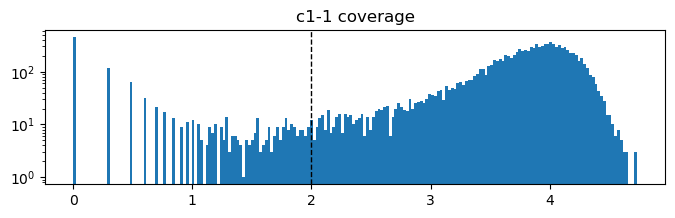

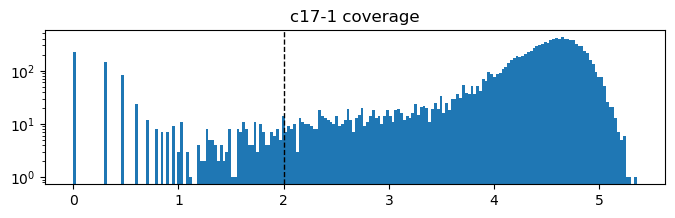

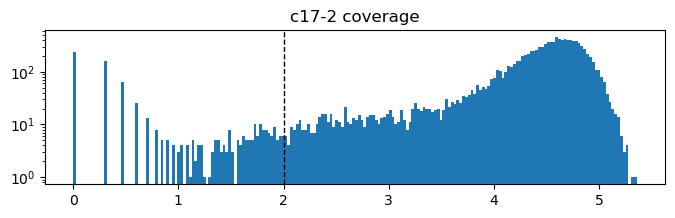

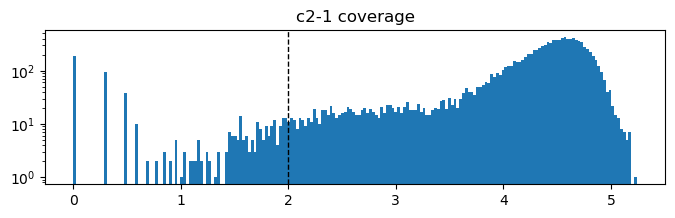

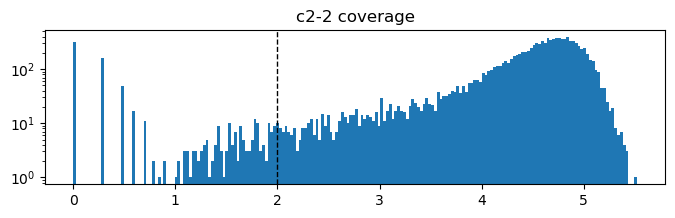

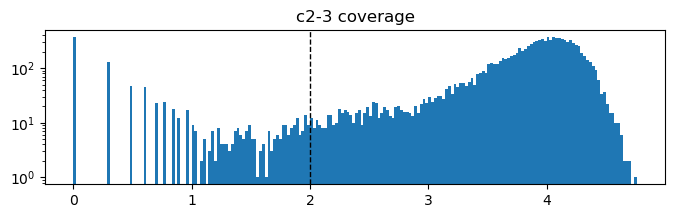

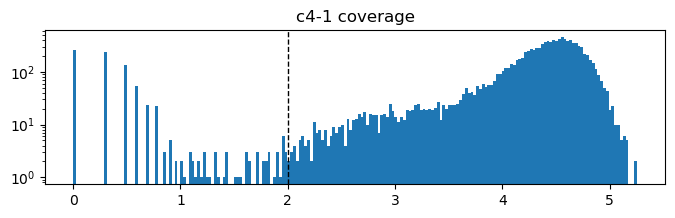

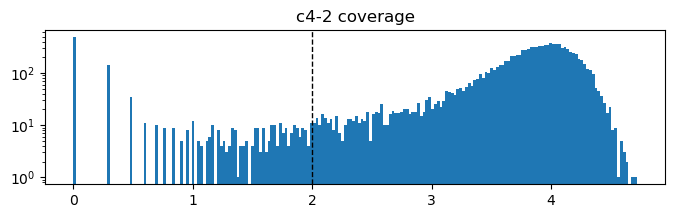

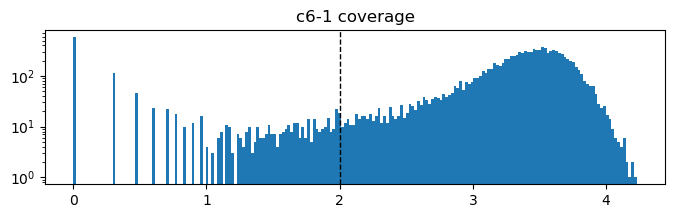

In [4]:
for ct in np.unique(d1.columns.get_level_values(0)):
    d2 = d1.loc[:, pd.IndexSlice[[ct], :, :]]
    for replicate in np.unique(d2.columns.get_level_values(1)):
        d3 = d2.loc[:, pd.IndexSlice[:, [replicate], :]]
        plt.figure(figsize=(8, 2))
        plt.hist(np.log10(1 + d3.sum(axis=1)), bins=200)
        plt.yscale("log")
        plt.title(f"{ct}-{replicate} coverage")
        plt.axvline(np.log10(100), color="k", ls="--", lw=1)
        #plt.axvline(np.log10(100000), color="r", ls="--", lw=1)
        plt.show()

In [5]:
d1_subdfs = []
for ct in np.unique(d1.columns.get_level_values(0)):
    d2 = d1.loc[:, pd.IndexSlice[[ct], :, :]]
    for replicate in np.unique(d2.columns.get_level_values(1)):
        d3 = d2.loc[:, pd.IndexSlice[:, [replicate], :]]
        filter_min = d3.min(axis=1) >= 10
        filter_sum = d3.apply(sorted, axis=1).str[2] >= 50  # second largest >= 50
        # filter_sum = d3.sum(axis=1) >= 100
        filter_max = d3.max(axis=1) < 1_000_000
        d3_filtered = d3[filter_sum & filter_min & filter_max]
        d1_subdfs.append(d3_filtered)
d1_filtered = pd.concat(d1_subdfs, axis=1)

In [6]:
# replacing data
d1_orig = d1
d1 = d1_filtered.fillna(0).astype(np.int32)

## Loading fits

In [7]:
fits = pd.read_csv("fit_results_utr5.csv")
fits

,cell_type,replicate,bin,wd1,wd2,psi,p1,n1,p2,n2
0,c2,1,1,0.187319,0.812681,0.979009,0.000321,0.291908,0.000727,2.760999
1,c2,1,2,0.209983,0.790017,0.980702,0.000192,0.347890,0.000374,3.025867
2,c2,1,3,0.205520,0.794480,0.974019,0.000238,0.392203,0.000444,3.208846
3,c2,1,4,0.065942,0.934058,0.998341,0.046023,0.114891,0.000083,1.268309
4,c2,2,1,0.205268,0.794732,0.957105,0.000180,0.386451,0.000457,2.745319
5,c2,2,2,0.174597,0.825403,0.952855,0.000345,0.443104,0.000496,2.890182
6,c2,2,3,0.200828,0.799172,0.953741,0.000297,0.433282,0.000530,2.832580
7,c2,2,4,0.172657,0.827343,0.999145,0.000035,0.156774,0.000051,1.903740
8,c2,3,1,0.155282,0.844718,0.999510,0.000780,0.149934,0.000833,2.184436
9,c2,3,2,0.175015,0.824985,0.999353,0.000547,0.174592,0.000995,2.419563


The distribution should be the most 'typical' one.

Let's assume that the most 'typical' distribution is the one with the closest to average read count value.

In [8]:
ref_ct, ref_rep, ref_bin = d1.columns[np.abs(d1.mean(axis=0) - d1.mean(axis=None)).argmin()]
reference_fit_id = (ref_ct, int(ref_rep), int(ref_bin))
reference_fit_id

('c2', 1, 3)

In [9]:
reference_fit_params = fits.set_index(["cell_type", "replicate", "bin"]).loc[reference_fit_id].to_dict()
reference_fit_params

{'wd1': 0.2055203265940162,
 'wd2': 0.7944796734059838,
 'psi': 0.9740189703281874,
 'p1': 0.0002377582206816,
 'n1': 0.3922030393063962,
 'p2': 0.0004439153470237,
 'n2': 3.2088458028367124}

In [10]:
# reference_fit_params = {
#     'wd1': 0.3868212945819003,
#     'wd2': 0.6131787054180997,
#     'psi': 0.9836780567472014,
#     'p1': 0.0011923047901109,
#     'n1': 0.6326889174306066,
#     'p2': 0.0029686888146403,
#     'n2': 4.3267421105465225
# }

In [11]:
def get_reference_rv(wd1, wd2, psi, p1, n1, p2, n2):
    wd_est = np.array([wd1, wd2])
    mixture_dist = pm.Mixture.dist(
        w=wd_est,
        comp_dists=[
            pm.ZeroInflatedNegativeBinomial.dist(psi=psi, p=p1, n=n1),
            pm.ZeroInflatedNegativeBinomial.dist(psi=psi, p=p2, n=n2),
        ])
    return mixture_dist

In [12]:
reference_rv = get_reference_rv(**reference_fit_params)

Checking the maximal theoretical value (it's unlikely that we are going to exceed it)

In [13]:
max_theoretical_value = d1.max(axis=None)
max_theoretical_value

253448

In [14]:
from scipy.spatial import KDTree


def get_discrete_icdf(rv, min_value=0, max_value=100_000):
    if min_value != 0:
        raise NotImplementedError
    logcdf = pm.logcdf(rv, np.arange(0, max_value + 1)).eval()
    cdf = np.exp(logcdf)
    round_tree = KDTree(cdf[:, np.newaxis], leafsize=10)

    def icdf(q: np.array):
        q = np.asarray(q)
        norm_vals = round_tree.query(q[:, np.newaxis], k=1)[1]
        # indices returned by the query are in fact the RV values as well
        return norm_vals

    return icdf

In [15]:
d1_normalized = d1.copy()

for (cell_type_id, replicate_id), fits_grp in tqdm(fits.groupby(by=["cell_type", "replicate"])):
    for i, lib_fit in fits_grp.iterrows():
        # Fitting library
        lib_key = (lib_fit["cell_type"], str(lib_fit["replicate"]), str(lib_fit["bin"]))
        lib = d1[lib_key].values
        libmax = lib.max()
        nanfilter = lib == 0
        lib_fit_params = lib_fit.iloc[3:].to_dict()

        # Calculating CDF
        lib_rv = get_reference_rv(**lib_fit_params)
        lib_logcdf = logcdf = pm.logcdf(lib_rv, np.arange(0, libmax + 1)).eval()
        lib_cdf = np.exp(lib_logcdf)
        lib_q = lib_cdf[lib]  # Since library starts at 0, cdf array is the inverse quantile function

        # Calculating quantiles
        reference_icdf_func = get_discrete_icdf(reference_rv, max_value=max_theoretical_value)
        lib_norm = reference_icdf_func(lib_q)

        # Normalizing CPMs
        lib_norm = lib_norm + 1
        lib_norm[nanfilter] = 0
        # # Notice the pseudocount
        lib_norm_cpm = lib_norm / lib_norm.sum() * 1_000_000
        d1_normalized[lib_key] = lib_norm

  0%|          | 0/9 [00:00<?, ?it/s]

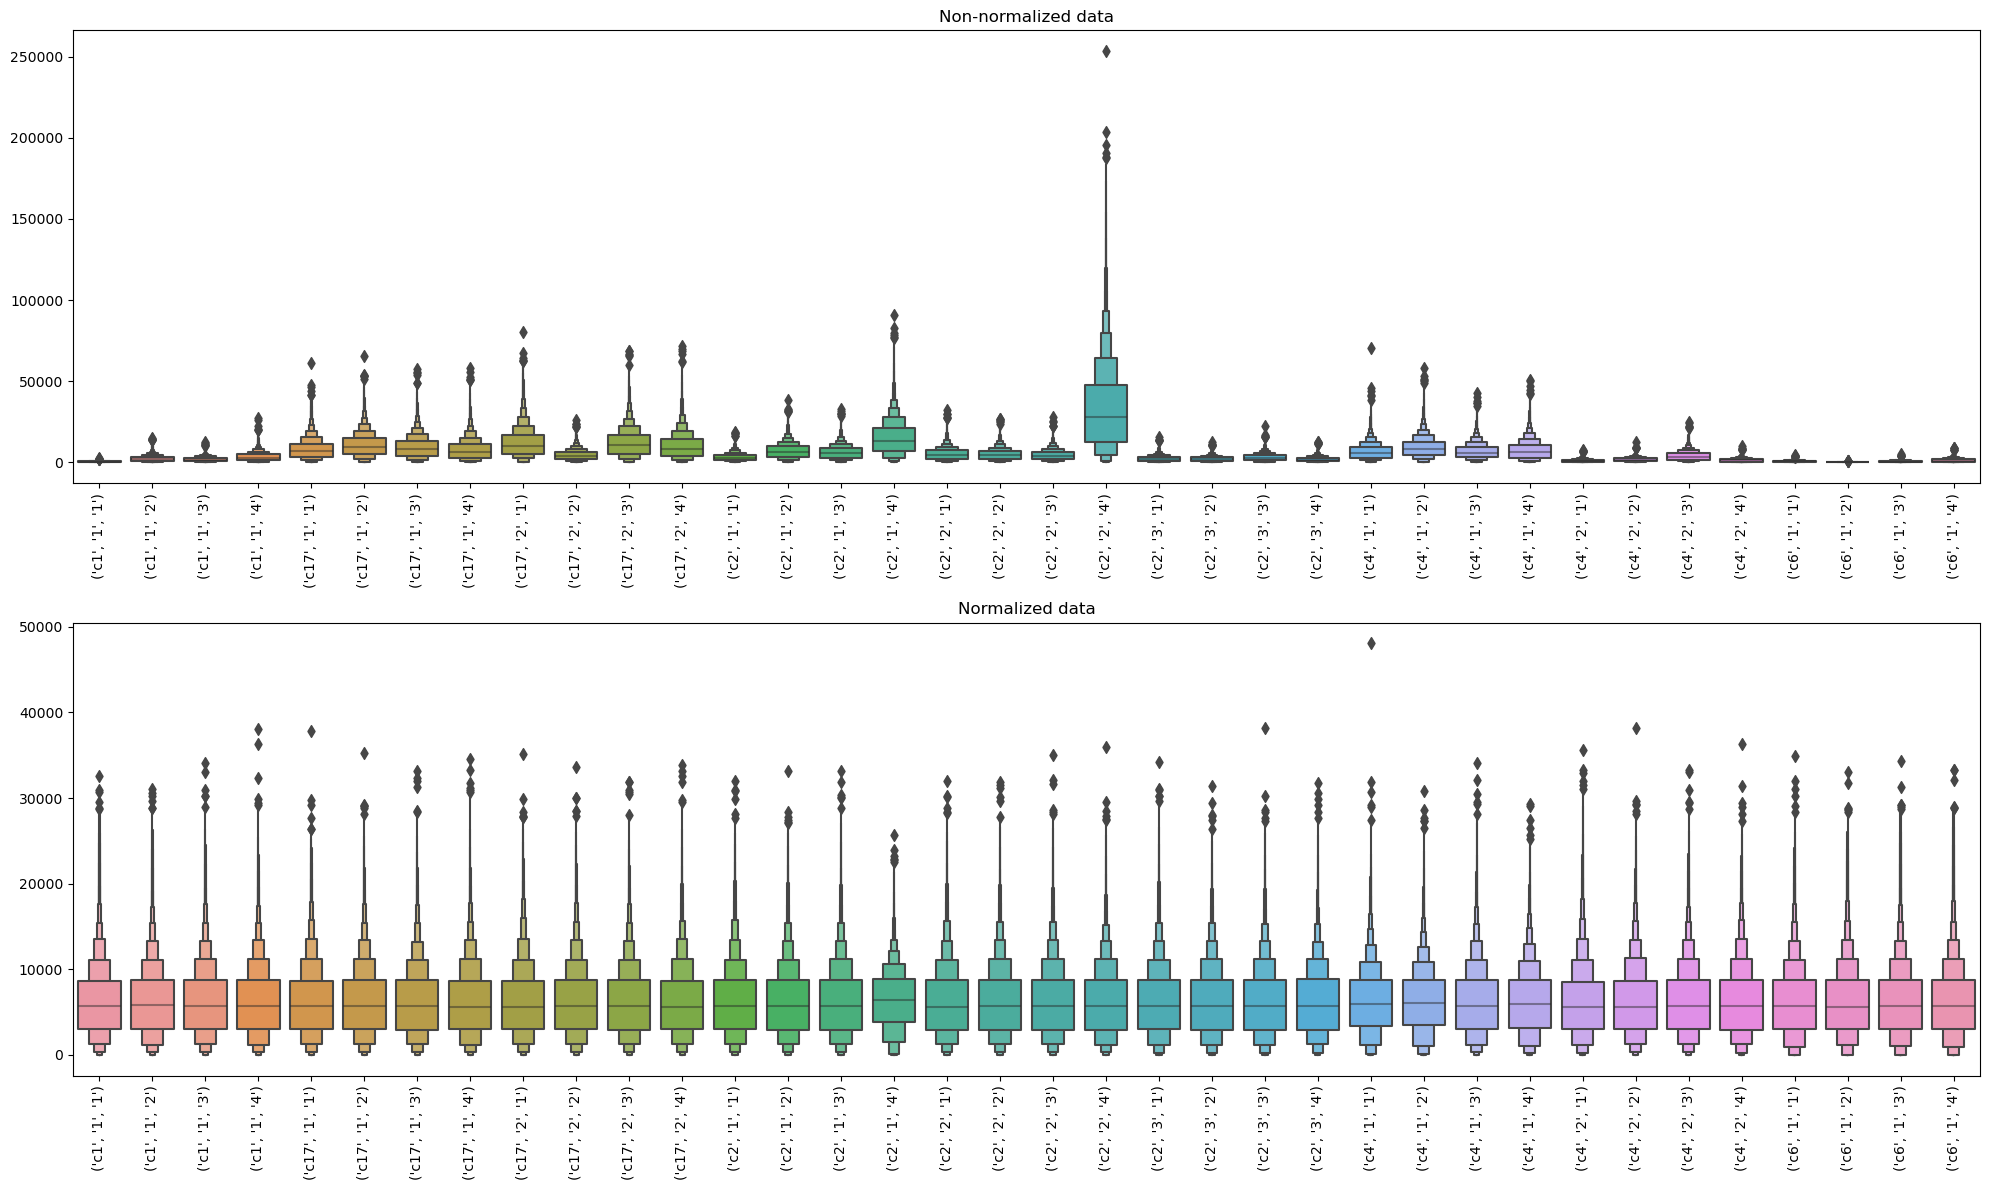

In [16]:
plt.figure(figsize=(20, 12))

plt.subplot(2, 1, 1)
sns.boxenplot(d1)
plt.xticks(rotation=90)
plt.title("Non-normalized data")

plt.subplot(2, 1, 2)
sns.boxenplot(d1_normalized)
plt.xticks(rotation=90)
plt.title("Normalized data")

plt.tight_layout()
plt.show()

## Preprocessing

In [17]:
d1_filtered = d1_normalized.copy()
d1_filtered.index.name = "seq"
d1_filtered

cell_type                                             c1                    \
replicate                                              1                     
bin                                                    1     2     3     4   
seq                                                                          
AAAAAAAATGTGACGGCGGCGGCGGCGGCGGCGGCGGCAGCGGCGGCGGC   614   395   685   815   
AAAAAATGGAGCGTGCGGCCTTGGCTGGTGGAGGAGGCGCAGGCAGCCCC  2490  2485  2600  3102   
AAAAAATGGAGGCGGAGCTGCGGCGGCGGCGGCGGCTGTGGCGGGACGTC  1987  2119  2124  1567   
AAAAAATGGCAGCGAGGGCGTTGGCGACGGCTGAGAGCGGAGCCGGCGTG  5010  4672  6439  7165   
AAAAAGAGGCCTGGGCCGGGAGTCCCCGCCCCTGGGCCCAGCCCTGGCCG  3193  2526  2885  2823   
...                                                  ...   ...   ...   ...   
GGGGGGCCCTGGGGGGCAGCTGCTGCTTTGGATTTTAATTTCTTTCTATG     0     0     0     0   
GTTTCTTTCTAGATCTGTGGGGGCTGGGGGAGTGTTCAGAGCTGACAGAG     0     0     0     0   
TGAGAGCTACTCTGGCTGATTTTTCCCTTCCGGTGAGGTTTGGAGCCCTG     0     0     0     0   
AAAATCAGGATCTCATTACAAGAGCCTTCTATTTTCTTTAACCTCCCCTT     0     0     0     0   
GCCAGGCTGAAAAGAAAAAAAAAGGCTGTGCCCTGGGCTTTTGCCTATTT     0     0     0     0   

cell_type                                             c17                    \
replicate                                               1                     
bin                                                     1     2     3     4   
seq                                                                           
AAAAAAAATGTGACGGCGGCGGCGGCGGCGGCGGCGGCAGCGGCGGCGGC   1610  1682  1173  2147   
AAAAAATGGAGCGTGCGGCCTTGGCTGGTGGAGGAGGCGCAGGCAGCCCC   2560  1198  1009  1536   
AAAAAATGGAGGCGGAGCTGCGGCGGCGGCGGCGGCTGTGGCGGGACGTC   2221  1534   931   808   
AAAAAATGGCAGCGAGGGCGTTGGCGACGGCTGAGAGCGGAGCCGGCGTG   3588  3527  4946  6857   
AAAAAGAGGCCTGGGCCGGGAGTCCCCGCCCCTGGGCCCAGCCCTGGCCG  11765  6369  3838  3597   
...                                                   ...   ...   ...   ...   
GGGGGGCCCTGGGGGGCAGCTGCTGCTTTGGATTTTAATTTCTTTCTATG      0     0     0     0   
GTTTCTTTCTAGATCTGTGGGGGCTGGGGGAGTGTTCAGAGCTGACAGAG      0     0     0     0   
TGAGAGCTACTCTGGCTGATTTTTCCCTTCCGGTGAGGTTTGGAGCCCTG      0     0     0     0   
AAAATCAGGATCTCATTACAAGAGCCTTCTATTTTCTTTAACCTCCCCTT      0     0     0     0   
GCCAGGCTGAAAAGAAAAAAAAAGGCTGTGCCCTGGGCTTTTGCCTATTT      0     0     0     0   

cell_type                                                        ...    c4  \
replicate                                               2        ...     1   
bin                                                     1     2  ...     3   
seq                                                              ...         
AAAAAAAATGTGACGGCGGCGGCGGCGGCGGCGGCGGCAGCGGCGGCGGC   1832  1578  ...   512   
AAAAAATGGAGCGTGCGGCCTTGGCTGGTGGAGGAGGCGCAGGCAGCCCC   2239   879  ...  2997   
AAAAAATGGAGGCGGAGCTGCGGCGGCGGCGGCGGCTGTGGCGGGACGTC   2574  1832  ...  1859   
AAAAAATGGCAGCGAGGGCGTTGGCGACGGCTGAGAGCGGAGCCGGCGTG   4451  4188  ...  5680   
AAAAAGAGGCCTGGGCCGGGAGTCCCCGCCCCTGGGCCCAGCCCTGGCCG  13752  6254  ...  2235   
...                                                   ...   ...  ...   ...   
GGGGGGCCCTGGGGGGCAGCTGCTGCTTTGGATTTTAATTTCTTTCTATG      0     0  ...     0   
GTTTCTTTCTAGATCTGTGGGGGCTGGGGGAGTGTTCAGAGCTGACAGAG      0     0  ...     0   
TGAGAGCTACTCTGGCTGATTTTTCCCTTCCGGTGAGGTTTGGAGCCCTG      0     0  ...     0   
AAAATCAGGATCTCATTACAAGAGCCTTCTATTTTCTTTAACCTCCCCTT      0     0  ...     0   
GCCAGGCTGAAAAGAAAAAAAAAGGCTGTGCCCTGGGCTTTTGCCTATTT      0     0  ...     0   

cell_type                                                                   \
replicate                                                    2               
bin                                                    4     1     2     3   
seq                                                                          
AAAAAAAATGTGACGGCGGCGGCGGCGGCGGCGGCGGCAGCGGCGGCGGC   218  1551   670   863   
AAAAAATGGAGCGTGCGGCCTTGGCTGGTGGAGGAGGCGCAGGCAGCCCC  3967  1604  2696  2755   
AAAA

In [18]:
d1_stacked = d1_filtered.stack(level=[0], dropna=False).reset_index()
d1_stacked.columns.name = None
d1_stacked

replicate                                                seq cell_type     1  \
bin                                                                        1   
0          AAAAAAAATGTGACGGCGGCGGCGGCGGCGGCGGCGGCAGCGGCGG...        c1   614   
1          AAAAAAAATGTGACGGCGGCGGCGGCGGCGGCGGCGGCAGCGGCGG...       c17  1610   
2          AAAAAAAATGTGACGGCGGCGGCGGCGGCGGCGGCGGCAGCGGCGG...        c2  1136   
3          AAAAAAAATGTGACGGCGGCGGCGGCGGCGGCGGCGGCAGCGGCGG...        c4  2375   
4          AAAAAAAATGTGACGGCGGCGGCGGCGGCGGCGGCGGCAGCGGCGG...        c6  4475   
...                                                      ...       ...   ...   
56830      GCCAGGCTGAAAAGAAAAAAAAAGGCTGTGCCCTGGGCTTTTGCCT...        c1     0   
56831      GCCAGGCTGAAAAGAAAAAAAAAGGCTGTGCCCTGGGCTTTTGCCT...       c17     0   
56832      GCCAGGCTGAAAAGAAAAAAAAAGGCTGTGCCCTGGGCTTTTGCCT...        c2     0   
56833      GCCAGGCTGAAAAGAAAAAAAAAGGCTGTGCCCTGGGCTTTTGCCT...        c4     0   
56834      GCCAGGCTGAAAAGAAAAAAAAAGGCTGTGCCCTGGGCTTTTGCCT...        c6   856   

replicate                         2                               3          \
bin           2     3     4       1       2       3       4       1       2   
0           395   685   815     NaN     NaN     NaN     NaN     NaN     NaN   
1          1682  1173  2147  1832.0  1578.0  1736.0  2054.0     NaN     NaN   
2           630   616   341   798.0   636.0   433.0   315.0  1450.0  1201.0   
3           975   512   218  1551.0   670.0   863.0   715.0     NaN     NaN   
4          2894  3129  2018     NaN     NaN     NaN     NaN     NaN     NaN   
...         ...   ...   ...     ...     ...     ...     ...     ...     ...   
56830         0     0     0     NaN     NaN     NaN     NaN     NaN     NaN   
56831         0     0     0     0.0     0.0     0.0     0.0     NaN     NaN   
56832         0     0     0     0.0     0.0     0.0     0.0     0.0     0.0   
56833         0     0     0     0.0     0.0     0.0     0.0     NaN     NaN   
56834      4562   551   351     NaN     NaN     NaN     NaN     NaN     NaN   

replicate                
bin            3      4  
0            NaN    NaN  
1            NaN    NaN  
2          664.0  664.0  
3            NaN    NaN  
4            NaN    NaN  
...          ...    ...  
56830        NaN    NaN  
56831        NaN    NaN  
56832        0.0    0.0  
56833        NaN    NaN  
56834        NaN    NaN  

[56835 rows x 14 columns]

In [19]:
d1_stacked = d1_stacked.set_index(["seq", "cell_type"]).stack(level=0).reset_index()

In [20]:
d1_split = d1_stacked.set_index("seq")
d1_split = d1_split[d1_split[["1", "2", "3", "4"]].sum(axis=1) != 0]
d1_split

bin,cell_type,replicate,1,2,3,4
seq,,,,,,
AAAAAAAATGTGACGGCGGCGGCGGCGGCGGCGGCGGCAGCGGCGGCGGC,c1,1,614.0,395.0,685.0,815.0
AAAAAAAATGTGACGGCGGCGGCGGCGGCGGCGGCGGCAGCGGCGGCGGC,c17,1,1610.0,1682.0,1173.0,2147.0
AAAAAAAATGTGACGGCGGCGGCGGCGGCGGCGGCGGCAGCGGCGGCGGC,c17,2,1832.0,1578.0,1736.0,2054.0
AAAAAAAATGTGACGGCGGCGGCGGCGGCGGCGGCGGCAGCGGCGGCGGC,c2,1,1136.0,630.0,616.0,341.0
AAAAAAAATGTGACGGCGGCGGCGGCGGCGGCGGCGGCAGCGGCGGCGGC,c2,2,798.0,636.0,433.0,315.0
...,...,...,...,...,...,...
GGGGGGCCCTGGGGGGCAGCTGCTGCTTTGGATTTTAATTTCTTTCTATG,c4,2,403.0,551.0,304.0,227.0
GTTTCTTTCTAGATCTGTGGGGGCTGGGGGAGTGTTCAGAGCTGACAGAG,c4,2,347.0,633.0,284.0,340.0
TGAGAGCTACTCTGGCTGATTTTTCCCTTCCGGTGAGGTTTGGAGCCCTG,c4,2,335.0,126.0,297.0,133.0


In [21]:
d1_split.to_csv("../../data/lib2/UTR5_zinb_norm_2024-06-04.csv")